В этом ноутбуке выполняется первичный анализ данных и подготовка единого набора признаков для моделей.

Цель — получить воспроизводимый train/test dataset с одинаковой схемой признаков, исключить утечки и извлечь информацию из технических характеристик и названия автомобиля.

# Инвентаризация файлов и изучения изначальной структуры

In [2]:
from pathlib import Path
import pandas as pd

DATA_DIR = Path(r"C:\temp\shift_ml\train_data")

files = []

for path in DATA_DIR.rglob("*"):
    if path.is_file():
        files.append(
            {
                "relative_path": str(path.relative_to(DATA_DIR)),
                "dataset_folder": path.parent.name,
                "file_name": path.name,
                "extension": path.suffix.lower(),
                "size_mb": round(path.stat().st_size / 1024**2, 3),
            }
        )

inventory = (
    pd.DataFrame(files)
    .sort_values(["dataset_folder", "file_name"])
    .reset_index(drop=True)
)

display(inventory)
display(
    inventory.groupby("extension", dropna=False)
    .agg(
        files=("file_name", "count"),
        total_size_mb=("size_mb", "sum"),
    )
    .sort_values("files", ascending=False)
)

inventory.to_csv(
    DATA_DIR / "data_files_inventory.csv",
    index=False,
    encoding="utf-8"
)

,relative_path,dataset_folder,file_name,extension,size_mb
0,dataset_1\data.csv,dataset_1,data.csv,.csv,0.038
1,dataset_10\data.csv,dataset_10,data.csv,.csv,0.210
2,dataset_11\data.csv,dataset_11,data.csv,.csv,0.205
3,dataset_12\data.csv,dataset_12,data.csv,.csv,0.200
4,dataset_13\data.parquet,dataset_13,data.parquet,.parquet,0.047
5,dataset_14\data.parquet,dataset_14,data.parquet,.parquet,0.046
6,dataset_15\data.csv,dataset_15,data.csv,.csv,0.202
7,dataset_16\data.parquet,dataset_16,data.parquet,.parquet,0.046
8,dataset_17\data.json,dataset_17,data.json,.json,1.532
9,dataset_18\data.parquet,dataset_18,data.parquet,.parquet,0.047


,files,total_size_mb
extension,,
.csv,24,6.138
.parquet,12,0.558
.xlsx,11,1.287
.json,7,10.961
.ipynb,1,0.025


# Анализ тестового набора данных и переменной Y

In [3]:
import pandas as pd

x_test_base = pd.read_csv(DATA_DIR / "X_test_base.csv")
y_train_base = pd.read_csv(DATA_DIR / "y_train_base.csv")

print("X_test_base shape:", x_test_base.shape)
display(x_test_base.head())
display(x_test_base.info())

print("\ny_train_base shape:", y_train_base.shape)
display(y_train_base.head())
display(y_train_base.info())
display(y_train_base.describe(include="all"))

pd.set_option('display.max_columns', None)

X_test_base shape: (8341, 22)


,car_id,Бренд,Год выпуска,Модель,Тип машины,Полное название,Исползование,КПП,Двигатель,Привод,...,Пробег,Цвет,Локация,Количество цилиндров,Тип кузова,Двери,Количество кресел,Оценка эксперта,Количество владельцев,Предложение
0,b2c2c5a9-6989-4596-bd8f-ce96c1720af9,SUBARU,2018.0,XV,SUV,2018 SUBARU XV 2.0I-L,USED,Automatic,"4 cyl, 2 L",AWD,...,44489,Grey / -,"MANDURAH, WA",4 cyl,SUV,4 Doors,5 Seats,4,3,Null
1,159a9504-c065-40a0-a47b-e97d4fd826b2,VOLKSWAGEN,2021.0,POLO,HATCHBACK,2021 VOLKSWAGEN POLO 70TSI TRENDLINE,USED,Automatic,"3 cyl, 1 L",Front,...,36612,White / Black,"WELSHPOOL, WA",3 cyl,HATCHBACK,5 Doors,5 Seats,2,7,NaN
2,4c7c09a0-5cea-43fa-bae0-8dd3207d8963,GWM,2022.0,HAVAL,SUV,2022 GWM HAVAL JOLION ULTRA HYBRID,USED,Automatic,"4 cyl, 1.5 L",Front,...,14651,Grey / Black,"MORLEY, WA",4 cyl,SUV,4 Doors,5 Seats,5,5,NaN
3,a2e7088a-3e5c-4811-86dc-543ff579970f,TOYOTA,2019.0,KLUGER,SUV,2019 TOYOTA KLUGER GRANDE (4X4),USED,Automatic,"6 cyl, 3.5 L",AWD,...,32493,Silver / Black Leather,"BERWICK, VIC",6 cyl,SUV,4 Doors,7 Seats,8,2,none
4,71648057-b854-4123-8fff-a3d85e9bab85,HYUNDAI,2019.0,KONA,SUV,2019 HYUNDAI KONA GO (FWD),USED,Automatic,"4 cyl, 2 L",Front,...,69436,White / -,"BUNGALOW, QLD",4 cyl,SUV,4 Doors,5 Seats,9,2,NaN


<class 'pandas.DataFrame'>
RangeIndex: 8341 entries, 0 to 8340
Data columns (total 22 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   car_id                 8341 non-null   str    
 1   Бренд                  8341 non-null   str    
 2   Год выпуска            8341 non-null   float64
 3   Модель                 8341 non-null   str    
 4   Тип машины             8328 non-null   str    
 5   Полное название        8341 non-null   str    
 6   Исползование           8341 non-null   str    
 7   КПП                    8341 non-null   str    
 8   Двигатель              8341 non-null   str    
 9   Привод                 8341 non-null   str    
 10  Топливо                8341 non-null   str    
 11  Расход                 8341 non-null   str    
 12  Пробег                 8341 non-null   str    
 13  Цвет                   8341 non-null   str    
 14  Локация                8105 non-null   str    
 15  Количество цили

None


y_train_base shape: (8340, 2)


,car_id,Цена
0,099ec55b-6322-4a9f-8d5e-0bed830c3023,28777
1,25e3e231-5efc-4032-abe9-794c0cba8295,62999
2,54f3b009-8e37-49cd-905a-9637d6bf135c,28999
3,b361a8ff-af76-40cc-9f54-811b6bfd5eb5,33950
4,671c0cce-667a-4f44-87e7-fe999e17e55e,77888


<class 'pandas.DataFrame'>
RangeIndex: 8340 entries, 0 to 8339
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   car_id  8340 non-null   str  
 1   Цена    8340 non-null   int64
dtypes: int64(1), str(1)
memory usage: 423.6 KB


None

,car_id,Цена
count,8340,8.340000e+03
unique,8340,NaN
top,099ec55b-6322-4a9f-8d5e-0bed830c3023,NaN
freq,1,NaN
mean,NaN,3.712697e+04
std,NaN,3.679723e+04
min,NaN,9.000000e+02
25%,NaN,1.944075e+04
50%,NaN,2.962000e+04
75%,NaN,4.399000e+04


# Что стало ясно

1. Все 48 dataset_* содержат по одному файлу, но форматы различаются: CSV, Parquet, Excel, JSON.

2. X_test_base.csv содержит 8 341 × 22.

3. y_train_base.csv содержит 8 340 строк, и car_id в нём уникален.

4. Целевая переменная в фактическом файле называется Цена.

5. В y_train_base нет пропусков в цене; минимальная цена — 900, то есть нулей нет. Однако для MAPE объекты с ценой 900 всё равно будут очень чувствительными: абсолютная ошибка на несколько тысяч даст огромный процент ошибки.

# Подробное изучение файлов

In [4]:
def read_dataset(path: Path) -> pd.DataFrame:
    suffix = path.suffix.lower()

    if suffix == ".csv":
        return pd.read_csv(path)

    if suffix == ".parquet":
        return pd.read_parquet(path)

    if suffix == ".xlsx":
        return pd.read_excel(path)

    if suffix == ".json":
        try:
            return pd.read_json(path)
        except ValueError:
            return pd.read_json(path, lines=True)

    raise ValueError(f"Неподдерживаемый формат: {suffix}")


profiles = []

for folder in sorted(DATA_DIR.glob("dataset_*")):
    files = list(folder.iterdir())

    if len(files) != 1:
        print(f"Проверить вручную: {folder.name}, файлов: {len(files)}")
        continue

    path = files[0]

    try:
        df = read_dataset(path)

        possible_keys = [
            col for col in df.columns
            if "id" in col.lower()
            or "car" in col.lower()
            or "vin" in col.lower()
        ]

        profiles.append(
            {
                "dataset": folder.name,
                "file": path.name,
                "format": path.suffix.lower(),
                "rows": df.shape[0],
                "columns_count": df.shape[1],
                "columns": " | ".join(map(str, df.columns)),
                "possible_keys": " | ".join(map(str, possible_keys)),
                "duplicate_rows": int(df.duplicated().sum()),
                "max_missing_pct": round(df.isna().mean().max() * 100, 2),
            }
        )

    except Exception as error:
        profiles.append(
            {
                "dataset": folder.name,
                "file": path.name,
                "format": path.suffix.lower(),
                "rows": None,
                "columns_count": None,
                "columns": None,
                "possible_keys": None,
                "duplicate_rows": None,
                "max_missing_pct": None,
                "error": repr(error),
            }
        )

datasets_profile = (
    pd.DataFrame(profiles)
    .sort_values("dataset")
    .reset_index(drop=True)
)

display(datasets_profile)

datasets_profile.to_csv(
    DATA_DIR / "datasets_profile.csv",
    index=False,
    encoding="utf-8-sig"
)

,dataset,file,format,rows,columns_count,columns,possible_keys,duplicate_rows,max_missing_pct
0,dataset_1,data.csv,.csv,174,22,car_id | Бренд | Год выпуска | Модель | Тип ма...,car_id,0,10.34
1,dataset_10,data.csv,.csv,1069,22,car_id | Бренд | Год выпуска | Модель | Тип ма...,car_id,423,21.89
2,dataset_11,data.csv,.csv,1047,22,car_id | Бренд | Год выпуска | Модель | Тип ма...,car_id,396,22.64
3,dataset_12,data.csv,.csv,1014,22,car_id | Бренд | Год выпуска | Модель | Тип ма...,car_id,369,20.91
4,dataset_13,data.parquet,.parquet,1109,22,car_id | Бренд | Год выпуска | Модель | Тип ма...,car_id,451,23.81
5,dataset_14,data.parquet,.parquet,1039,22,car_id | Бренд | Год выпуска | Модель | Тип ма...,car_id,412,25.51
6,dataset_15,data.csv,.csv,1028,22,car_id | Бренд | Год выпуска | Модель | Тип ма...,car_id,391,24.22
7,dataset_16,data.parquet,.parquet,1056,22,car_id | Бренд | Год выпуска | Модель | Тип ма...,car_id,411,23.67
8,dataset_17,data.json,.json,1057,22,car_id | Бренд | Год выпуска | Модель | Тип ма...,car_id,383,18.45
9,dataset_18,data.parquet,.parquet,1069,22,car_id | Бренд | Год выпуска | Модель | Тип ма...,car_id,425,24.98


Все показанные dataset_1–dataset_23 имеют одинаковую схему: 22 столбца и car_id. При этом внутри каждого набора очень много полных дубликатов строк: примерно 35–42%.

# Ближашая адача

48 источников с карточками автомобилей

→ часть машин повторяется между источниками

→ у записей могут различаться заполненность или качество полей

→ нужно собрать единую feature-таблицу по car_id

→ затем соединить train-автомобили с ценой по car_id

→ отдельно сформировать test-таблицу

# Риски и возможные ошибки
Нельзя делать concat(axis=1) между признаками и y_train_base: связь должна быть только через car_id.

Если повторяющиеся записи имеют один car_id, на этапе валидации будем делить данные по автомобилям, а не по строкам.

In [5]:
X_base = pd.read_csv(DATA_DIR / "X_test_base.csv")
y_base = pd.read_csv(DATA_DIR / "y_train_base.csv")

X_base["car_id"] = X_base["car_id"].astype("string").str.strip()
y_base["car_id"] = y_base["car_id"].astype("string").str.strip()

x_ids = set(X_base["car_id"].dropna())
y_ids = set(y_base["car_id"].dropna())

def dataset_number(path: Path) -> int:
    return int(path.parent.name.split("_")[-1])


dataset_files = sorted(
    DATA_DIR.glob("dataset_*/data.*"),
    key=dataset_number
)

source_audit_rows = []
all_source_parts = []

for path in dataset_files:
    df = read_dataset(path).copy()
    source_name = path.parent.name

    if "car_id" not in df.columns:
        raise ValueError(f"В {source_name} нет car_id")

    df["car_id"] = df["car_id"].astype("string").str.strip()
    ids = set(df["car_id"].dropna())

    source_audit_rows.append(
        {
            "dataset": source_name,
            "rows": len(df),
            "unique_car_id": df["car_id"].nunique(),
            "duplicate_car_id_rows": int(
                df["car_id"].duplicated(keep=False).sum()
            ),
            "exact_duplicate_rows": int(df.duplicated().sum()),
            "unique_ids_in_y_train": len(ids & y_ids),
            "unique_ids_in_X_base": len(ids & x_ids),
            "unique_ids_unknown": len(ids - y_ids - x_ids),
            "same_schema_as_X_base": list(df.columns) == list(X_base.columns),
        }
    )

    all_source_parts.append(
        df[["car_id"]].assign(dataset=source_name)
    )

source_audit = pd.DataFrame(source_audit_rows)
display(source_audit)

all_source_ids = pd.concat(all_source_parts, ignore_index=True)

car_id_coverage = (
    all_source_ids
    .groupby("car_id", as_index=False)
    .agg(
        source_count=("dataset", "nunique"),
        total_rows_in_sources=("dataset", "size"),
    )
)

car_id_coverage["in_y_train"] = car_id_coverage["car_id"].isin(y_ids)
car_id_coverage["in_X_base"] = car_id_coverage["car_id"].isin(x_ids)

coverage_summary = (
    car_id_coverage
    .groupby(["in_y_train", "in_X_base"], dropna=False)
    .agg(
        unique_car_id=("car_id", "count"),
        mean_sources_per_car=("source_count", "mean"),
        max_sources_per_car=("source_count", "max"),
    )
    .reset_index()
)

print("Покрытие car_id во всех dataset_*:")
display(coverage_summary)

print("Сколько источников в среднем содержит один car_id:")
display(
    car_id_coverage["source_count"]
    .value_counts()
    .sort_index()
    .rename_axis("sources_per_car")
    .reset_index(name="car_id_count")
)

base_id_audit = pd.DataFrame(
    {
        "metric": [
            "Уникальных car_id в y_train_base",
            "Уникальных car_id в X_test_base",
            "Пересечение y_train_base и X_test_base",
            "Только в y_train_base",
            "Только в X_test_base",
        ],
        "value": [
            len(y_ids),
            len(x_ids),
            len(y_ids & x_ids),
            len(y_ids - x_ids),
            len(x_ids - y_ids),
        ],
    }
)

print("Связь y_train_base и X_test_base:")
display(base_id_audit)

source_audit.to_csv(
    DATA_DIR / "source_audit.csv",
    index=False,
    encoding="utf-8-sig",
)

car_id_coverage.to_csv(
    DATA_DIR / "car_id_coverage.csv",
    index=False,
    encoding="utf-8-sig",
)

,dataset,rows,unique_car_id,duplicate_car_id_rows,exact_duplicate_rows,unique_ids_in_y_train,unique_ids_in_X_base,unique_ids_unknown,same_schema_as_X_base
0,dataset_1,174,174,0,0,174,0,0,True
1,dataset_2,1026,174,1006,399,174,0,0,True
2,dataset_3,1056,174,1038,392,174,0,0,True
3,dataset_4,1076,174,1066,411,174,0,0,True
4,dataset_5,993,174,973,383,174,0,0,True
5,dataset_6,979,174,961,357,174,0,0,True
6,dataset_7,1079,174,1062,450,174,0,0,True
7,dataset_8,1052,174,1036,409,174,0,0,True
8,dataset_9,1084,174,1072,430,174,0,0,True
9,dataset_10,1069,174,1052,423,174,0,0,True


Покрытие car_id во всех dataset_*:


,in_y_train,in_X_base,unique_car_id,mean_sources_per_car,max_sources_per_car
0,True,False,8340,1.0,1


Сколько источников в среднем содержит один car_id:


,sources_per_car,car_id_count
0,1,8340


Связь y_train_base и X_test_base:


,metric,value
0,Уникальных car_id в y_train_base,8340
1,Уникальных car_id в X_test_base,8341
2,Пересечение y_train_base и X_test_base,0
3,Только в y_train_base,8340
4,Только в X_test_base,8341


Нужно понять, чем отличаются строки одного car_id и можно ли безопасно собрать их в одну запись.

Выберем несколько автомобилей из dataset_2, покажем все их строки и посчитаем, в каких колонках есть конфликтующие значения.

In [6]:
dataset_2 = pd.read_csv(DATA_DIR / "dataset_2" / "data.csv")

print("Размер dataset_2:", dataset_2.shape)
print("Уникальных автомобилей:", dataset_2["car_id"].nunique())

cars_per_id = dataset_2["car_id"].value_counts()

print("\nРаспределение числа строк на один car_id:")
display(cars_per_id.describe())

sample_ids = cars_per_id.head(3).index.tolist()

for car_id in sample_ids:
    print(f"\n{'=' * 100}")
    print(f"car_id: {car_id}")
    print(f"Количество строк: {cars_per_id[car_id]}")
    
    car_rows = dataset_2.loc[dataset_2["car_id"] == car_id].copy()
    display(car_rows)

Размер dataset_2: (1026, 22)
Уникальных автомобилей: 174

Распределение числа строк на один car_id:


count    174.000000
mean       5.896552
std        3.243613
min        1.000000
25%        3.000000
50%        6.000000
75%        9.000000
max       11.000000
Name: count, dtype: float64


car_id: f4ca53ea-0df8-48d4-9326-5fcd934aa123
Количество строк: 11


,car_id,Бренд,Год выпуска,Модель,Тип машины,Полное название,Исползование,КПП,Двигатель,Привод,Топливо,Расход,Пробег,Цвет,Локация,Количество цилиндров,Тип кузова,Двери,Количество кресел,Оценка эксперта,Количество владельцев,Предложение
9,f4ca53ea-0df8-48d4-9326-5fcd934aa123,HOLDEN,2014.0,TRAX,3MT TRUE VALUE AUTO,2014 HOLDEN TRAX 2014 HOLDEN TRAX LS TJ AUTO MY14,USED,Automatic,-,Other,-,-,162892,Black / -,"VICTORIA PARK, WA",-,WAGON,NaN,NaN,8.0,3.0,12074.0
218,f4ca53ea-0df8-48d4-9326-5fcd934aa123,NaN,NaN,TRAX,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-,NaN,NaN,NaN,NaN,NaN,NaN
219,f4ca53ea-0df8-48d4-9326-5fcd934aa123,HOLDEN,2014.0,NaN,3MT TRUE VALUE AUTO,2014 HOLDEN TRAX 2014 HOLDEN TRAX LS TJ AUTO MY14,USED,Automatic,-,Other,-,-,162892,Black / -,"VICTORIA PARK, WA",NaN,WAGON,NaN,NaN,8.0,3.0,12074.0
220,f4ca53ea-0df8-48d4-9326-5fcd934aa123,HOLDEN,2014.0,TRAX,3MT TRUE VALUE AUTO,2014 HOLDEN TRAX 2014 HOLDEN TRAX LS TJ AUTO MY14,USED,Automatic,-,Other,-,-,162892,Black / -,"VICTORIA PARK, WA",-,WAGON,NaN,NaN,8.0,3.0,12074.0
221,f4ca53ea-0df8-48d4-9326-5fcd934aa123,HOLDEN,2014.0,TRAX,3MT TRUE VALUE AUTO,2014 HOLDEN TRAX 2014 HOLDEN TRAX LS TJ AUTO MY14,USED,Automatic,-,Other,-,-,162892,Black / -,"VICTORIA PARK, WA",-,WAGON,NaN,NaN,8.0,3.0,12074.0
222,f4ca53ea-0df8-48d4-9326-5fcd934aa123,HOLDEN,2014.0,TRAX,3MT TRUE VALUE AUTO,2014 HOLDEN TRAX 2014 HOLDEN TRAX LS TJ AUTO MY14,USED,Automatic,-,Other,-,-,162892,Black / -,"VICTORIA PARK, WA",-,WAGON,NaN,NaN,8.0,3.0,12074.0
223,f4ca53ea-0df8-48d4-9326-5fcd934aa123,HOLDEN,2014.0,TRAX,3MT TRUE VALUE AUTO,2014 HOLDEN TRAX 2014 HOLDEN TRAX LS TJ AUTO MY14,USED,Automatic,-,Other,-,-,162892,Black / -,"VICTORIA PARK, WA",-,WAGON,NaN,NaN,8.0,3.0,12074.0
224,f4ca53ea-0df8-48d4-9326-5fcd934aa123,HOLDEN,2014.0,TRAX,3MT TRUE VALUE AUTO,2014 HOLDEN TRAX 2014 HOLDEN TRAX LS TJ AUTO MY14,USED,Automatic,-,Other,-,-,162892,Black / -,"VICTORIA PARK, WA",-,WAGON,NaN,NaN,8.0,3.0,12074.0
225,f4ca53ea-0df8-48d4-9326-5fcd934aa123,HOLDEN,2014.0,TRAX,3MT TRUE VALUE AUTO,2014 HOLDEN TRAX 2014 HOLDEN TRAX LS TJ AUTO MY14,USED,Automatic,-,Other,-,-,162892,Black / -,"VICTORIA PARK, WA",-,WAGON,NaN,NaN,8.0,3.0,12074.0
226,f4ca53ea-0df8-48d4-9326-5fcd934aa123,HOLDEN,2014.0,TRAX,3MT TRUE VALUE AUTO,2014 HOLDEN TRAX 2014 HOLDEN TRAX LS TJ AUTO MY14,USED,Automatic,-,Other,-,-,162892,Black / -,"VICTORIA PARK, WA",-,WAGON,NaN,NaN,8.0,3.0,12074.0



car_id: 88418cf3-9273-4950-8b13-c367a354db19
Количество строк: 11


,car_id,Бренд,Год выпуска,Модель,Тип машины,Полное название,Исползование,КПП,Двигатель,Привод,Топливо,Расход,Пробег,Цвет,Локация,Количество цилиндров,Тип кузова,Двери,Количество кресел,Оценка эксперта,Количество владельцев,Предложение
46,88418cf3-9273-4950-8b13-c367a354db19,JEEP,2015.0,CHEROKEE,SUV,2015 JEEP CHEROKEE TRAILHAWK (4X4),USED,Automatic,"6 cyl, 3.2 L",4WD,UNLEADED,10 L / 100 km,144089,Silver / Black,"DUDLEY PARK, WA",6 cyl,SUV,4 Doors,5 Seats,8.0,5.0,20016.0
379,88418cf3-9273-4950-8b13-c367a354db19,NaN,2015.0,NaN,NaN,2015 JEEP CHEROKEE TRAILHAWK (4X4),NaN,NaN,"6 cyl, 3.2 L",NaN,NaN,10 L / 100 km,144089,NaN,NaN,NaN,NaN,4 Doors,NaN,NaN,NaN,NaN
380,88418cf3-9273-4950-8b13-c367a354db19,JEEP,2015.0,CHEROKEE,SUV,2015 JEEP CHEROKEE TRAILHAWK (4X4),USED,Automatic,"6 cyl, 3.2 L",4WD,UNLEADED,10 L / 100 km,144089,Silver / Black,"DUDLEY PARK, WA",6 cyl,SUV,4 Doors,5 Seats,8.0,5.0,20016.0
381,88418cf3-9273-4950-8b13-c367a354db19,JEEP,2015.0,CHEROKEE,SUV,2015 JEEP CHEROKEE TRAILHAWK (4X4),USED,Automatic,"6 cyl, 3.2 L",4WD,UNLEADED,10 L / 100 km,144089,Silver / Black,"DUDLEY PARK, WA",6 cyl,SUV,NaN,5 Seats,8.0,5.0,20016.0
382,88418cf3-9273-4950-8b13-c367a354db19,JEEP,2015.0,CHEROKEE,SUV,2015 JEEP CHEROKEE TRAILHAWK (4X4),USED,Automatic,NaN,4WD,UNLEADED,10 L / 100 km,144089,Silver / Black,"DUDLEY PARK, WA",6 cyl,SUV,4 Doors,5 Seats,8.0,5.0,20016.0
383,88418cf3-9273-4950-8b13-c367a354db19,JEEP,NaN,CHEROKEE,SUV,NaN,USED,Automatic,"6 cyl, 3.2 L",4WD,UNLEADED,10 L / 100 km,NaN,Silver / Black,"DUDLEY PARK, WA",6 cyl,SUV,4 Doors,5 Seats,8.0,5.0,20016.0
384,88418cf3-9273-4950-8b13-c367a354db19,JEEP,2015.0,CHEROKEE,SUV,2015 JEEP CHEROKEE TRAILHAWK (4X4),USED,Automatic,"6 cyl, 3.2 L",4WD,UNLEADED,NaN,144089,Silver / Black,"DUDLEY PARK, WA",6 cyl,SUV,4 Doors,5 Seats,8.0,5.0,20016.0
385,88418cf3-9273-4950-8b13-c367a354db19,JEEP,2015.0,CHEROKEE,SUV,2015 JEEP CHEROKEE TRAILHAWK (4X4),USED,Automatic,"6 cyl, 3.2 L",4WD,UNLEADED,10 L / 100 km,144089,Silver / Black,"DUDLEY PARK, WA",6 cyl,SUV,4 Doors,5 Seats,8.0,5.0,20016.0
386,88418cf3-9273-4950-8b13-c367a354db19,JEEP,2015.0,CHEROKEE,SUV,2015 JEEP CHEROKEE TRAILHAWK (4X4),USED,Automatic,"6 cyl, 3.2 L",4WD,UNLEADED,10 L / 100 km,144089,Silver / Black,"DUDLEY PARK, WA",6 cyl,SUV,4 Doors,5 Seats,8.0,5.0,20016.0
387,88418cf3-9273-4950-8b13-c367a354db19,JEEP,2015.0,CHEROKEE,SUV,2015 JEEP CHEROKEE TRAILHAWK (4X4),USED,Automatic,"6 cyl, 3.2 L",4WD,UNLEADED,10 L / 100 km,144089,Silver / Black,"DUDLEY PARK, WA",6 cyl,SUV,4 Doors,5 Seats,8.0,5.0,20016.0



car_id: bd8bcee8-bb4f-41cf-beb6-b9a2b712bc43
Количество строк: 11


,car_id,Бренд,Год выпуска,Модель,Тип машины,Полное название,Исползование,КПП,Двигатель,Привод,Топливо,Расход,Пробег,Цвет,Локация,Количество цилиндров,Тип кузова,Двери,Количество кресел,Оценка эксперта,Количество владельцев,Предложение
54,bd8bcee8-bb4f-41cf-beb6-b9a2b712bc43,MG,2022.0,HS,ALTO NORTH SHORE MG,2022 MG HS +EV PHEV EXCITE,NEW,Automatic,"4 cyl, 1.5 L",Front,HYBRID,1.7 L / 100 km,24,White / Knight Black,"ARTARMON, NSW",4 cyl,SUV,5 Doors,5 Seats,8.0,2.0,49495.0
430,bd8bcee8-bb4f-41cf-beb6-b9a2b712bc43,MG,NaN,NaN,ALTO NORTH SHORE MG,NaN,NaN,NaN,NaN,NaN,HYBRID,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5 Seats,NaN,NaN,NaN
431,bd8bcee8-bb4f-41cf-beb6-b9a2b712bc43,MG,2022.0,HS,NaN,2022 MG HS +EV PHEV EXCITE,NEW,Automatic,"4 cyl, 1.5 L",Front,HYBRID,1.7 L / 100 km,24,White / Knight Black,"ARTARMON, NSW",4 cyl,SUV,5 Doors,5 Seats,8.0,2.0,49495.0
432,bd8bcee8-bb4f-41cf-beb6-b9a2b712bc43,NaN,2022.0,HS,ALTO NORTH SHORE MG,2022 MG HS +EV PHEV EXCITE,NEW,Automatic,"4 cyl, 1.5 L",Front,NaN,1.7 L / 100 km,24,White / Knight Black,"ARTARMON, NSW",4 cyl,SUV,5 Doors,NaN,8.0,2.0,49495.0
433,bd8bcee8-bb4f-41cf-beb6-b9a2b712bc43,MG,2022.0,HS,ALTO NORTH SHORE MG,2022 MG HS +EV PHEV EXCITE,NEW,Automatic,"4 cyl, 1.5 L",Front,HYBRID,1.7 L / 100 km,24,White / Knight Black,"ARTARMON, NSW",4 cyl,SUV,5 Doors,5 Seats,8.0,2.0,49495.0
434,bd8bcee8-bb4f-41cf-beb6-b9a2b712bc43,MG,2022.0,HS,ALTO NORTH SHORE MG,2022 MG HS +EV PHEV EXCITE,NEW,Automatic,"4 cyl, 1.5 L",Front,HYBRID,1.7 L / 100 km,24,White / Knight Black,"ARTARMON, NSW",4 cyl,SUV,5 Doors,5 Seats,8.0,2.0,49495.0
435,bd8bcee8-bb4f-41cf-beb6-b9a2b712bc43,MG,2022.0,HS,ALTO NORTH SHORE MG,2022 MG HS +EV PHEV EXCITE,NEW,Automatic,"4 cyl, 1.5 L",Front,HYBRID,1.7 L / 100 km,24,White / Knight Black,"ARTARMON, NSW",4 cyl,SUV,5 Doors,5 Seats,8.0,2.0,49495.0
436,bd8bcee8-bb4f-41cf-beb6-b9a2b712bc43,MG,2022.0,HS,ALTO NORTH SHORE MG,2022 MG HS +EV PHEV EXCITE,NEW,Automatic,"4 cyl, 1.5 L",Front,HYBRID,1.7 L / 100 km,24,White / Knight Black,"ARTARMON, NSW",4 cyl,SUV,5 Doors,5 Seats,8.0,2.0,49495.0
437,bd8bcee8-bb4f-41cf-beb6-b9a2b712bc43,MG,2022.0,HS,ALTO NORTH SHORE MG,2022 MG HS +EV PHEV EXCITE,NEW,Automatic,"4 cyl, 1.5 L",Front,HYBRID,1.7 L / 100 km,24,White / Knight Black,"ARTARMON, NSW",4 cyl,SUV,5 Doors,5 Seats,8.0,2.0,49495.0
438,bd8bcee8-bb4f-41cf-beb6-b9a2b712bc43,MG,2022.0,HS,ALTO NORTH SHORE MG,2022 MG HS +EV PHEV EXCITE,NEW,Automatic,"4 cyl, 1.5 L",Front,HYBRID,1.7 L / 100 km,24,White / Knight Black,"ARTARMON, NSW",4 cyl,SUV,5 Doors,5 Seats,8.0,2.0,49495.0


Аудит конфликтов по всем датасетам:

In [7]:
all_train_raw = []

for path in DATA_DIR.glob("dataset_*/data.*"):
    df = read_dataset(path).copy()
    df["source_dataset"] = path.parent.name
    all_train_raw.append(df)

train_raw = pd.concat(all_train_raw, ignore_index=True)

print("Размер сырых train-данных:", train_raw.shape)
print("Уникальных car_id:", train_raw["car_id"].nunique())

feature_columns = [
    col for col in train_raw.columns
    if col not in {"car_id", "source_dataset"}
]

conflict_report = []

for column in feature_columns:
    n_unique_values = (
        train_raw
        .groupby("car_id")[column]
        .nunique(dropna=True)
    )

    conflict_report.append(
        {
            "column": column,
            "cars_with_multiple_non_null_values": int((n_unique_values > 1).sum()),
            "share_of_cars_with_conflict_pct": round(
                (n_unique_values > 1).mean() * 100,
                2
            ),
            "max_unique_values_per_car": int(n_unique_values.max()),
        }
    )

conflict_report = (
    pd.DataFrame(conflict_report)
    .sort_values(
        "cars_with_multiple_non_null_values",
        ascending=False
    )
    .reset_index(drop=True)
)

display(conflict_report)

Размер сырых train-данных: (49679, 23)
Уникальных car_id: 8340


,column,cars_with_multiple_non_null_values,share_of_cars_with_conflict_pct,max_unique_values_per_car
0,Бренд,0,0.0,1
1,Год выпуска,0,0.0,1
2,Модель,0,0.0,1
3,Тип машины,0,0.0,1
4,Полное название,0,0.0,1
5,Исползование,0,0.0,1
6,КПП,0,0.0,1
7,Двигатель,0,0.0,1
8,Привод,0,0.0,1
9,Топливо,0,0.0,1


# Итого выводы по структуре

Внутри каждого dataset_* один и тот же car_id встречается от 1 до 11 раз.

Повторные строки не содержат конфликтующих значений: для каждого признака у одного автомобиля максимум одно различное непустое значение.

Различия между строками — это в основном частично скрытые / пропущенные поля и полные дубликаты.

После объединения всех источников есть 49 679 сырых строк, но ровно 8 340 уникальных автомобилей — столько же, сколько строк в y_train_base.csv.

# Что это означает для задачи

Нужно собрать для каждого car_id одну каноническую строку:

несколько частично заполненных записей одного автомобиля

→ взять единственное доступное непустое значение по каждому полю

→ одна полная карточка автомобиля

Предложение выглядит подозрительно. В примерах это числовое значение, очень похожее на стоимость объявления. 

# Новые импорты (объединение ноутбуков)

In [9]:
from pathlib import Path
import numpy as np
import pandas as pd

DATA_DIR = Path(r"C:\temp\shift_ml\train_data")
PROCESSED_DIR = DATA_DIR.parent / "data" / "processed"
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

X_test = pd.read_csv(DATA_DIR / "X_test_base.csv")
y_train = pd.read_csv(DATA_DIR / "y_train_base.csv")

X_test["car_id"] = X_test["car_id"].astype("string").str.strip()
y_train["car_id"] = y_train["car_id"].astype("string").str.strip()


def read_dataset(path: Path) -> pd.DataFrame:
    suffix = path.suffix.lower()

    if suffix == ".csv":
        return pd.read_csv(path)

    if suffix == ".parquet":
        return pd.read_parquet(path)

    if suffix == ".xlsx":
        return pd.read_excel(path)

    if suffix == ".json":
        try:
            return pd.read_json(path)
        except ValueError:
            return pd.read_json(path, lines=True)

    raise ValueError(f"Неподдерживаемый формат: {suffix}")


def dataset_number(path: Path) -> int:
    return int(path.parent.name.split("_")[-1])


dataset_files = sorted(
    DATA_DIR.glob("dataset_*/data.*"),
    key=dataset_number
)

raw_parts = []

for path in dataset_files:
    df = read_dataset(path).copy()
    df["car_id"] = df["car_id"].astype("string").str.strip()
    raw_parts.append(df)

train_raw = pd.concat(raw_parts, ignore_index=True)

print("Сырые train-данные:", train_raw.shape)
print("Уникальных car_id:", train_raw["car_id"].nunique())

Сырые train-данные: (49679, 22)
Уникальных car_id: 8340


Теперь агрегируем строки. Здесь для каждого столбца берём первое найденное непустое значение. 

In [10]:
feature_columns = [column for column in X_test.columns if column != "car_id"]


def first_non_null(series: pd.Series):
    non_null_values = series.dropna()

    if non_null_values.empty:
        return pd.NA

    return non_null_values.iloc[0]


X_train = (
    train_raw
    .groupby("car_id", sort=False)[feature_columns]
    .agg(first_non_null)
    .reset_index()
)

# Ставим порядок колонок точно как в X_test.
X_train = X_train[X_test.columns]

print("X_train после агрегации:", X_train.shape)
print("X_test:", X_test.shape)

X_train после агрегации: (8340, 22)
X_test: (8341, 22)


Соединяем признаки и target только по идентификатору:

In [11]:
missing_tokens = {
    "",
    "-",
    "null",
    "none",
    "nan",
    "n/a",
}

def clean_offer_column(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()

    offer = (
        df["Предложение"]
        .astype("string")
        .str.strip()
        .str.lower()
        .replace(missing_tokens, pd.NA)
    )

    df["Предложение"] = pd.to_numeric(
        offer,
        errors="coerce",
    )

    return df


X_train = clean_offer_column(X_train)
X_test = clean_offer_column(X_test)

In [13]:
train = X_train.merge(
    y_train,
    on="car_id",
    how="inner",
    validate="one_to_one",
)

print("Итоговый train:", train.shape)

display(train.head())

Итоговый train: (8340, 23)


,car_id,Бренд,Год выпуска,Модель,Тип машины,Полное название,Исползование,КПП,Двигатель,Привод,Топливо,Расход,Пробег,Цвет,Локация,Количество цилиндров,Тип кузова,Двери,Количество кресел,Оценка эксперта,Количество владельцев,Предложение,Цена
0,65e4207d-80c1-47a9-9ce8-51a5e5cfca5c,GWM,2022.0,HAVAL,SPRINGWOOD GWM HAVAL,2022 GWM HAVAL H6 ULTRA AWD,DEMO,Automatic,"4 cyl, 2 L",AWD,PREMIUM,9.8 L / 100 km,244,Grey / Black,"SPRINGWOOD, QLD",4 cyl,SUV,4 Doors,5 Seats,4.0,5.0,32145.0,38812
1,331006ba-098d-4b5b-9f05-3cf9544c30ec,FORD,2014.0,TERRITORY,SUV,2014 FORD TERRITORY TITANIUM (4X4),USED,Automatic,"6 cyl, 2.7 L",AWD,DIESEL,9 L / 100 km,202408,White / -,"PENRITH, NSW",6 cyl,SUV,4 Doors,7 Seats,6.0,6.0,15949.0,15950
2,43a44ee6-5293-4a42-a04f-faf3bf0967b4,NISSAN,2021.0,X-TRAIL,SUV,2021 NISSAN X-TRAIL TI (4WD),USED,Automatic,"4 cyl, 2.5 L",4WD,UNLEADED,8.3 L / 100 km,23301,White / -,"WEST FOOTSCRAY, VIC",4 cyl,SUV,4 Doors,5 Seats,4.0,7.0,39616.0,41990
3,383affa3-d8da-4ad0-9bd7-91f48c1c00ac,VOLVO,2022.0,XC60,SUV,2022 VOLVO XC60 B5 MOMENTUM MHEV,USED,Automatic,"4 cyl, 2 L",AWD,HYBRID,7.6 L / 100 km,17359,White / Black,"SOUTH BUNBURY, WA",4 cyl,SUV,4 Doors,5 Seats,1.0,9.0,70449.0,69900
4,e100c33a-b78c-479d-8edf-5734b2bde7fd,RENAULT,2018.0,KOLEOS,SUV,2018 RENAULT KOLEOS INTENS (4X4),USED,Automatic,"4 cyl, 2 L",4WD,DIESEL,6.1 L / 100 km,100456,White / -,"RINGWOOD, VIC",4 cyl,SUV,4 Doors,5 Seats,1.0,8.0,22895.0,27950


Сравниваем пропуски train и test после агрегации:

In [14]:
missingness_report = pd.DataFrame(
    {
        "train_missing_pct": X_train[feature_columns].isna().mean().mul(100),
        "test_missing_pct": X_test[feature_columns].isna().mean().mul(100),
    }
)

missingness_report["difference_test_minus_train"] = (
    missingness_report["test_missing_pct"]
    - missingness_report["train_missing_pct"]
)

missingness_report = (
    missingness_report
    .sort_values("test_missing_pct", ascending=False)
    .round(2)
)

display(missingness_report)

,train_missing_pct,test_missing_pct,difference_test_minus_train
Предложение,0.00,100.00,100.00
Количество кресел,9.76,10.48,0.72
Двери,9.20,9.83,0.63
Локация,2.55,2.83,0.28
Тип кузова,1.59,1.75,0.16
Тип машины,0.16,0.16,-0.00
Модель,0.00,0.00,0.00
Год выпуска,0.00,0.00,0.00
Бренд,0.00,0.00,0.00
Полное название,0.00,0.00,0.00


Проверяем столбец Предложение:

In [15]:
offer = pd.to_numeric(train["Предложение"], errors="coerce")
price = train["Цена"]

mask = offer.notna() & price.notna()

offer_audit = pd.DataFrame(
    {
        "metric": [
            "Всего объектов",
            "Непустых значений в Предложение",
            "Доля непустых Предложение, %",
            "Точных совпадений Предложение и Цена",
            "Доля точных совпадений среди непустых, %",
            "Корреляция Предложение и Цена",
            "MAPE, если прогнозировать значением Предложение, %",
        ],
        "value": [
            len(train),
            int(mask.sum()),
            round(mask.mean() * 100, 2),
            int((offer[mask] == price[mask]).sum()),
            round((offer[mask] == price[mask]).mean() * 100, 2),
            round(offer[mask].corr(price[mask]), 4),
            round(
                (
                    np.abs(price[mask] - offer[mask])
                    / price[mask]
                ).mean() * 100,
                4,
            ),
        ],
    }
)

display(offer_audit)

display(
    train.loc[
        mask,
        ["car_id", "Бренд", "Модель", "Год выпуска", "Предложение", "Цена"]
    ].head(10)
)

,metric,value
0,Всего объектов,8340.0000
1,Непустых значений в Предложение,8340.0000
2,"Доля непустых Предложение, %",100.0000
3,Точных совпадений Предложение и Цена,0.0000
4,"Доля точных совпадений среди непустых, %",0.0000
5,Корреляция Предложение и Цена,0.9938
6,"MAPE, если прогнозировать значением Предложени...",8.3118


,car_id,Бренд,Модель,Год выпуска,Предложение,Цена
0,65e4207d-80c1-47a9-9ce8-51a5e5cfca5c,GWM,HAVAL,2022.0,32145.0,38812
1,331006ba-098d-4b5b-9f05-3cf9544c30ec,FORD,TERRITORY,2014.0,15949.0,15950
2,43a44ee6-5293-4a42-a04f-faf3bf0967b4,NISSAN,X-TRAIL,2021.0,39616.0,41990
3,383affa3-d8da-4ad0-9bd7-91f48c1c00ac,VOLVO,XC60,2022.0,70449.0,69900
4,e100c33a-b78c-479d-8edf-5734b2bde7fd,RENAULT,KOLEOS,2018.0,22895.0,27950
5,85356769-9239-48d6-9c83-a918b7a8e66f,KIA,PICANTO,2019.0,20659.0,20999
6,5e974caa-66e1-4be3-8899-67dd5c116bb0,AUDI,A1,2021.0,27832.0,32888
7,97c4619a-0a2b-4f26-aa57-d5ccd780bd79,MITSUBISHI,TRITON,2022.0,50290.0,55990
8,f9a39f6d-cfdb-475a-a2b2-d4a3d414cffe,TOYOTA,RAV4,2019.0,35064.0,36990
9,c322cca0-b4f2-42be-b40a-df689287c6e0,FORD,FAIRLANE,2004.0,7466.0,8999


И сохраняем собранные данные как промежуточный воспроизводимый артефакт:

In [16]:
X_train.to_parquet(
    PROCESSED_DIR / "X_train_canonical.parquet",
    index=False,
)

train.to_parquet(
    PROCESSED_DIR / "train_canonical.parquet",
    index=False,
)

X_test.to_parquet(
    PROCESSED_DIR / "X_test_canonical.parquet",
    index=False,
)

Нельзя оставлять Предложение. Это самый важный leakage-риск, который мы пока обнаружили.

In [17]:
ID_COLUMN = "car_id"
TARGET_COLUMN = "Цена"

EXCLUDED_COLUMNS = [
    ID_COLUMN,
    TARGET_COLUMN,
    "Предложение",
]

feature_columns = [
    col for col in train.columns
    if col not in EXCLUDED_COLUMNS
]

print(f"Количество признаков: {len(feature_columns)}")
print(feature_columns)


X = train[feature_columns].copy()
y = train[TARGET_COLUMN].copy()

X_final_test = X_test[feature_columns].copy()

Количество признаков: 20
['Бренд', 'Год выпуска', 'Модель', 'Тип машины', 'Полное название', 'Исползование', 'КПП', 'Двигатель', 'Привод', 'Топливо', 'Расход', 'Пробег', 'Цвет', 'Локация', 'Количество цилиндров', 'Тип кузова', 'Двери', 'Количество кресел', 'Оценка эксперта', 'Количество владельцев']


# Новые импорты (объединение ноутбуков)

In [18]:
from pathlib import Path
import numpy as np
import pandas as pd

DATA_DIR = Path(r"C:\temp\shift_ml\train_data")
PROCESSED_DIR = DATA_DIR.parent / "data" / "processed"
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

X_test = pd.read_csv(DATA_DIR / "X_test_base.csv")
y_train = pd.read_csv(DATA_DIR / "y_train_base.csv")

X_test["car_id"] = X_test["car_id"].astype("string").str.strip()
y_train["car_id"] = y_train["car_id"].astype("string").str.strip()


def read_dataset(path: Path) -> pd.DataFrame:
    suffix = path.suffix.lower()

    if suffix == ".csv":
        return pd.read_csv(path)

    if suffix == ".parquet":
        return pd.read_parquet(path)

    if suffix == ".xlsx":
        return pd.read_excel(path)

    if suffix == ".json":
        try:
            return pd.read_json(path)
        except ValueError:
            return pd.read_json(path, lines=True)

    raise ValueError(f"Неподдерживаемый формат: {suffix}")


def dataset_number(path: Path) -> int:
    return int(path.parent.name.split("_")[-1])


dataset_files = sorted(
    DATA_DIR.glob("dataset_*/data.*"),
    key=dataset_number
)

raw_parts = []

for path in dataset_files:
    df = read_dataset(path).copy()
    df["car_id"] = df["car_id"].astype("string").str.strip()
    raw_parts.append(df)

train_raw = pd.concat(raw_parts, ignore_index=True)

print("Сырые train-данные:", train_raw.shape)
print("Уникальных car_id:", train_raw["car_id"].nunique())

Сырые train-данные: (49679, 22)
Уникальных car_id: 8340


In [19]:
feature_columns = [column for column in X_test.columns if column != "car_id"]


def first_non_null(series: pd.Series):
    non_null_values = series.dropna()

    if non_null_values.empty:
        return pd.NA

    return non_null_values.iloc[0]


X_train = (
    train_raw
    .groupby("car_id", sort=False)[feature_columns]
    .agg(first_non_null)
    .reset_index()
)

# Ставим порядок колонок точно как в X_test.
X_train = X_train[X_test.columns]

print("X_train после агрегации:", X_train.shape)
print("X_test:", X_test.shape)

X_train после агрегации: (8340, 22)
X_test: (8341, 22)


In [20]:
train = X_train.merge(
    y_train,
    on="car_id",
    how="inner",
    validate="one_to_one",
)

print("Итоговый train:", train.shape)

assert len(train) == len(y_train)
assert train["Цена"].isna().sum() == 0
assert train["car_id"].nunique() == len(train)

display(train.head())

Итоговый train: (8340, 23)


,car_id,Бренд,Год выпуска,Модель,Тип машины,Полное название,Исползование,КПП,Двигатель,Привод,Топливо,Расход,Пробег,Цвет,Локация,Количество цилиндров,Тип кузова,Двери,Количество кресел,Оценка эксперта,Количество владельцев,Предложение,Цена
0,65e4207d-80c1-47a9-9ce8-51a5e5cfca5c,GWM,2022.0,HAVAL,SPRINGWOOD GWM HAVAL,2022 GWM HAVAL H6 ULTRA AWD,DEMO,Automatic,"4 cyl, 2 L",AWD,PREMIUM,9.8 L / 100 km,244,Grey / Black,"SPRINGWOOD, QLD",4 cyl,SUV,4 Doors,5 Seats,4.0,5.0,32145,38812
1,331006ba-098d-4b5b-9f05-3cf9544c30ec,FORD,2014.0,TERRITORY,SUV,2014 FORD TERRITORY TITANIUM (4X4),USED,Automatic,"6 cyl, 2.7 L",AWD,DIESEL,9 L / 100 km,202408,White / -,"PENRITH, NSW",6 cyl,SUV,4 Doors,7 Seats,6.0,6.0,15949,15950
2,43a44ee6-5293-4a42-a04f-faf3bf0967b4,NISSAN,2021.0,X-TRAIL,SUV,2021 NISSAN X-TRAIL TI (4WD),USED,Automatic,"4 cyl, 2.5 L",4WD,UNLEADED,8.3 L / 100 km,23301,White / -,"WEST FOOTSCRAY, VIC",4 cyl,SUV,4 Doors,5 Seats,4.0,7.0,39616,41990
3,383affa3-d8da-4ad0-9bd7-91f48c1c00ac,VOLVO,2022.0,XC60,SUV,2022 VOLVO XC60 B5 MOMENTUM MHEV,USED,Automatic,"4 cyl, 2 L",AWD,HYBRID,7.6 L / 100 km,17359,White / Black,"SOUTH BUNBURY, WA",4 cyl,SUV,4 Doors,5 Seats,1.0,9.0,70449,69900
4,e100c33a-b78c-479d-8edf-5734b2bde7fd,RENAULT,2018.0,KOLEOS,SUV,2018 RENAULT KOLEOS INTENS (4X4),USED,Automatic,"4 cyl, 2 L",4WD,DIESEL,6.1 L / 100 km,100456,White / -,"RINGWOOD, VIC",4 cyl,SUV,4 Doors,5 Seats,1.0,8.0,22895,27950


In [21]:
feature_columns = [column for column in X_test.columns if column != "car_id"]


def first_non_null(series: pd.Series):
    non_null_values = series.dropna()

    if non_null_values.empty:
        return pd.NA

    return non_null_values.iloc[0]


X_train = (
    train_raw
    .groupby("car_id", sort=False)[feature_columns]
    .agg(first_non_null)
    .reset_index()
)

# Ставим порядок колонок точно как в X_test.
X_train = X_train[X_test.columns]

print("X_train после агрегации:", X_train.shape)
print("X_test:", X_test.shape)

assert X_train.shape[0] == 8340
assert X_train["car_id"].nunique() == 8340
assert list(X_train.columns) == list(X_test.columns)
assert X_train["car_id"].duplicated().sum() == 0

X_train после агрегации: (8340, 22)
X_test: (8341, 22)


In [22]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

TARGET_COLUMN = "Цена"

y = train[TARGET_COLUMN].copy()

target_audit = pd.DataFrame(
    {
        "metric": [
            "Количество объектов",
            "Пропусков",
            "Нулевых цен",
            "Отрицательных цен",
            "Минимум",
            "1-й процентиль",
            "5-й процентиль",
            "25-й процентиль",
            "Медиана",
            "Среднее",
            "75-й процентиль",
            "95-й процентиль",
            "99-й процентиль",
            "Максимум",
        ],
        "value": [
            len(y),
            int(y.isna().sum()),
            int((y == 0).sum()),
            int((y < 0).sum()),
            y.min(),
            y.quantile(0.01),
            y.quantile(0.05),
            y.quantile(0.25),
            y.median(),
            y.mean(),
            y.quantile(0.75),
            y.quantile(0.95),
            y.quantile(0.99),
            y.max(),
        ],
    }
)

display(target_audit)

,metric,value
0,Количество объектов,8.340000e+03
1,Пропусков,0.000000e+00
2,Нулевых цен,0.000000e+00
3,Отрицательных цен,0.000000e+00
4,Минимум,9.000000e+02
5,1-й процентиль,5.995000e+03
6,5-й процентиль,9.499000e+03
7,25-й процентиль,1.944075e+04
8,Медиана,2.962000e+04
9,Среднее,3.712697e+04


Ценовые сегменты для будущего анализа ошибок

In [23]:
price_bins = [
    0,
    5_000,
    10_000,
    20_000,
    30_000,
    50_000,
    75_000,
    100_000,
    200_000,
    np.inf,
]

price_labels = [
    "0–5k",
    "5k–10k",
    "10k–20k",
    "20k–30k",
    "30k–50k",
    "50k–75k",
    "75k–100k",
    "100k–200k",
    "200k+",
]

price_segment = pd.cut(
    y,
    bins=price_bins,
    labels=price_labels,
    include_lowest=True,
)

price_segment_report = (
    price_segment
    .value_counts(dropna=False)
    .sort_index()
    .rename("count")
    .to_frame()
)

price_segment_report["share_pct"] = (
    price_segment_report["count"] / len(y) * 100
).round(2)

display(price_segment_report)

,count,share_pct
Цена,,
0–5k,45,0.54
5k–10k,519,6.22
10k–20k,1800,21.58
20k–30k,2077,24.90
30k–50k,2385,28.60
50k–75k,936,11.22
75k–100k,315,3.78
100k–200k,202,2.42
200k+,61,0.73


Графики распределения цены

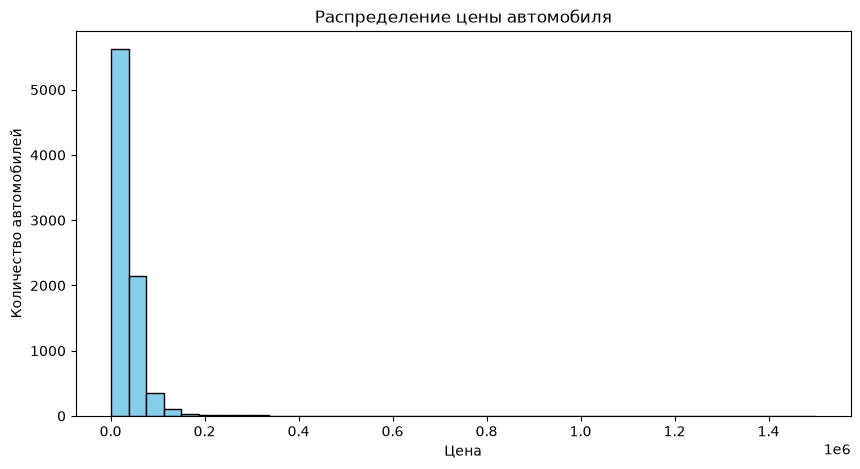

In [24]:
plt.figure(figsize=(10, 5))
plt.hist(y, bins=40, color="skyblue", edgecolor="black")
plt.title("Распределение цены автомобиля")
plt.xlabel("Цена")
plt.ylabel("Количество автомобилей")
plt.show()

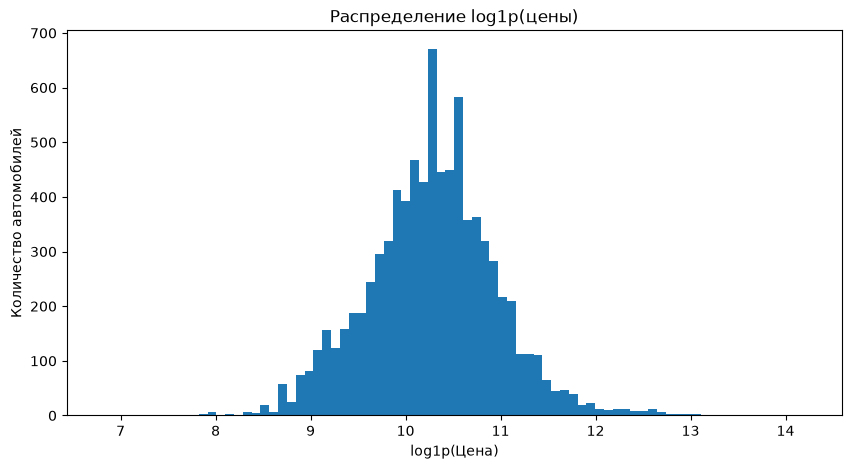

In [25]:
plt.figure(figsize=(10, 5))
plt.hist(np.log1p(y), bins=80)
plt.title("Распределение log1p(цены)")
plt.xlabel("log1p(Цена)")
plt.ylabel("Количество автомобилей")
plt.show()

In [26]:
low_price_thresholds = [1_000, 3_000, 5_000, 10_000]

low_price_report = pd.DataFrame(
    {
        "threshold": low_price_thresholds,
        "cars_with_price_less_or_equal": [
            int((y <= threshold).sum())
            for threshold in low_price_thresholds
        ],
        "share_pct": [
            round((y <= threshold).mean() * 100, 2)
            for threshold in low_price_thresholds
        ],
    }
)

display(low_price_report)

,threshold,cars_with_price_less_or_equal,share_pct
0,1000,1,0.01
1,3000,12,0.14
2,5000,45,0.54
3,10000,564,6.76


В данных уже встречались значения вроде "-", "Null" и "none". Нормализуем их.

In [27]:
MISSING_TOKENS = {
    "",
    "-",
    "null",
    "none",
    "nan",
    "n/a",
    "na",
}

def count_text_missing_tokens(df: pd.DataFrame) -> pd.Series:
    result = {}

    for column in df.columns:
        if column == "car_id":
            continue

        if pd.api.types.is_object_dtype(df[column]) or pd.api.types.is_string_dtype(df[column]):
            values = (
                df[column]
                .astype("string")
                .str.strip()
                .str.lower()
            )

            result[column] = int(values.isin(MISSING_TOKENS).sum())
        else:
            result[column] = 0

    return pd.Series(result)


text_missing_report = pd.DataFrame(
    {
        "train_text_missing_tokens": count_text_missing_tokens(X_train),
        "test_text_missing_tokens": count_text_missing_tokens(X_test),
    }
)

text_missing_report["total"] = (
    text_missing_report["train_text_missing_tokens"]
    + text_missing_report["test_text_missing_tokens"]
)

text_missing_report = (
    text_missing_report
    .sort_values("total", ascending=False)
)

display(text_missing_report)

,train_text_missing_tokens,test_text_missing_tokens,total
Предложение,0,3329,3329
Расход,812,869,1681
Количество цилиндров,801,857,1658
Двигатель,801,857,1658
Топливо,319,313,632
КПП,123,120,243
Пробег,61,65,126
Полное название,0,0,0
Год выпуска,0,0,0
Бренд,0,0,0


Проверка на полные совпадения признаков. Она покажет, есть ли разные car_id с идентичными карточками автомобиля, но разными ценами.

In [28]:
MODEL_FEATURES = [
    column
    for column in train.columns
    if column not in {"car_id", "Цена", "Предложение"}
]

duplicate_feature_mask = train.duplicated(
    subset=MODEL_FEATURES,
    keep=False,
)

feature_duplicates = train.loc[
    duplicate_feature_mask,
    ["car_id", "Цена"] + MODEL_FEATURES,
].sort_values(MODEL_FEATURES)

print("Строк с полностью совпадающими признаками:", len(feature_duplicates))
print("Уникальных автомобилей в таких группах:", feature_duplicates["car_id"].nunique())

display(feature_duplicates.head(20))

Строк с полностью совпадающими признаками: 2
Уникальных автомобилей в таких группах: 2


,car_id,Цена,Бренд,Год выпуска,Модель,Тип машины,Полное название,Исползование,КПП,Двигатель,Привод,Топливо,Расход,Пробег,Цвет,Локация,Количество цилиндров,Тип кузова,Двери,Количество кресел,Оценка эксперта,Количество владельцев
5183,f8cfd273-15a0-4ea5-8c11-6128b5bac9fa,66500,MAZDA,2023.0,CX-9,SUTHERLAND MAZDA NEW CARS,2023 MAZDA CX-9 TOURING (AWD),DEMO,Automatic,"4 cyl, 2.5 L",AWD,UNLEADED,8.8 L / 100 km,120,Grey / -,"KIRRAWEE, NSW",4 cyl,SUV,4 Doors,7 Seats,1.0,3.0
6110,89fee07d-e674-4bb1-a29f-bb3876e4a128,55800,MAZDA,2023.0,CX-9,SUTHERLAND MAZDA NEW CARS,2023 MAZDA CX-9 TOURING (AWD),DEMO,Automatic,"4 cyl, 2.5 L",AWD,UNLEADED,8.8 L / 100 km,120,Grey / -,"KIRRAWEE, NSW",4 cyl,SUV,4 Doors,7 Seats,1.0,3.0


# ============================================================
# EDA 2. Нормализация пропусков и извлечение числовых признаков
# ============================================================

Сделаем детерминированную очистку и извлечём числа из технических строк. 

In [29]:
MISSING_TOKENS = {
    "",
    "-",
    "null",
    "none",
    "nan",
    "n/a",
    "na",
}


def normalize_text_missing_values(df: pd.DataFrame) -> pd.DataFrame:
    result = df.copy()

    for column in result.columns:
        if column == "car_id":
            continue

        if (
            pd.api.types.is_object_dtype(result[column])
            or pd.api.types.is_string_dtype(result[column])
        ):
            cleaned = (
                result[column]
                .astype("string")
                .str.strip()
            )

            result[column] = cleaned.mask(
                cleaned.str.lower().isin(MISSING_TOKENS),
                pd.NA,
            )

    return result


X_train_clean = normalize_text_missing_values(X_train)
X_test_clean = normalize_text_missing_values(X_test)

assert list(X_train_clean.columns) == list(X_test_clean.columns)

Теперь извлечём числовые признаки, не удаляя исходные:

In [30]:
def add_parsed_features(df: pd.DataFrame) -> pd.DataFrame:
    result = df.copy()

    # Пробег: "44489" -> 44489.0
    result["Пробег_число"] = pd.to_numeric(
        result["Пробег"],
        errors="coerce",
    )

    # Расход: "7 L / 100 km" -> 7.0
    result["Расход_л_на_100км"] = pd.to_numeric(
        result["Расход"]
        .astype("string")
        .str.extract(r"(\d+(?:\.\d+)?)", expand=False),
        errors="coerce",
    )

    # Двигатель: "4 cyl, 2 L" -> 4.0 и 2.0
    engine = result["Двигатель"].astype("string")

    result["Двигатель_цилиндры"] = pd.to_numeric(
        engine.str.extract(r"(\d+)\s*cyl", expand=False),
        errors="coerce",
    )

    result["Двигатель_объём_л"] = pd.to_numeric(
        engine.str.extract(r"(\d+(?:\.\d+)?)\s*L\b", expand=False),
        errors="coerce",
    )

    # "4 Doors" -> 4.0
    result["Двери_число"] = pd.to_numeric(
        result["Двери"]
        .astype("string")
        .str.extract(r"(\d+)", expand=False),
        errors="coerce",
    )

    # "5 Seats" -> 5.0
    result["Кресла_число"] = pd.to_numeric(
        result["Количество кресел"]
        .astype("string")
        .str.extract(r"(\d+)", expand=False),
        errors="coerce",
    )

    # "MANDURAH, WA" -> "WA"
    result["Штат"] = (
        result["Локация"]
        .astype("string")
        .str.extract(r",\s*([A-Z]{2,3})$", expand=False)
    )

    return result


X_train_features = add_parsed_features(X_train_clean)
X_test_features = add_parsed_features(X_test_clean)

assert list(X_train_features.columns) == list(X_test_features.columns)

In [31]:
parsed_columns = [
    "Пробег_число",
    "Расход_л_на_100км",
    "Двигатель_цилиндры",
    "Двигатель_объём_л",
    "Двери_число",
    "Кресла_число",
    "Штат",
]

parsing_report = pd.DataFrame(
    {
        "train_missing_pct": (
            X_train_features[parsed_columns]
            .isna()
            .mean()
            .mul(100)
        ),
        "test_missing_pct": (
            X_test_features[parsed_columns]
            .isna()
            .mean()
            .mul(100)
        ),
    }
).round(2)

display(parsing_report)

display(
    X_train_features[
        [
            "Двигатель",
            "Расход",
            "Пробег",
            "Двери",
            "Количество кресел",
            "Локация",
        ]
        + parsed_columns
    ].head(10)
)

,train_missing_pct,test_missing_pct
Пробег_число,3.29,3.61
Расход_л_на_100км,9.74,10.42
Двигатель_цилиндры,10.34,10.83
Двигатель_объём_л,9.60,10.29
Двери_число,9.20,9.83
Кресла_число,9.76,10.48
Штат,2.55,2.84


,Двигатель,Расход,Пробег,Двери,Количество кресел,Локация,Пробег_число,Расход_л_на_100км,Двигатель_цилиндры,Двигатель_объём_л,Двери_число,Кресла_число,Штат
0,"4 cyl, 2 L",9.8 L / 100 km,244,4 Doors,5 Seats,"SPRINGWOOD, QLD",244,9.8,4,2.0,4,5,QLD
1,"6 cyl, 2.7 L",9 L / 100 km,202408,4 Doors,7 Seats,"PENRITH, NSW",202408,9.0,6,2.7,4,7,NSW
2,"4 cyl, 2.5 L",8.3 L / 100 km,23301,4 Doors,5 Seats,"WEST FOOTSCRAY, VIC",23301,8.3,4,2.5,4,5,VIC
3,"4 cyl, 2 L",7.6 L / 100 km,17359,4 Doors,5 Seats,"SOUTH BUNBURY, WA",17359,7.6,4,2.0,4,5,WA
4,"4 cyl, 2 L",6.1 L / 100 km,100456,4 Doors,5 Seats,"RINGWOOD, VIC",100456,6.1,4,2.0,4,5,VIC
5,"4 cyl, 1.2 L",5.8 L / 100 km,58762,5 Doors,5 Seats,"VICTORIA PARK, WA",58762,5.8,4,1.2,5,5,WA
6,"3 cyl, 1 L",5.4 L / 100 km,16691,5 Doors,5 Seats,"RYDE, NSW",16691,5.4,3,1.0,5,5,NSW
7,"4 cyl, 2.4 L",8.6 L / 100 km,18407,4 Doors,5 Seats,"BUNGALOW, QLD",18407,8.6,4,2.4,4,5,QLD
8,"4 cyl, 2 L",6.5 L / 100 km,97790,5 Doors,5 Seats,"PAKENHAM, VIC",97790,6.5,4,2.0,5,5,VIC
9,"8 cyl, 5.4 L",15 L / 100 km,203910,4 Doors,5 Seats,"BLAIR ATHOL, SA",203910,15.0,8,5.4,4,5,SA


Это уже полезные числовые признаки для моделей. Исходные текстовые столбцы пока сохраняем: например, Двигатель может содержать дополнительные комбинации, которые не сводятся только к объёму и цилиндрам.